# Logistic Regression: Cross-Entropy and Geometry

CSI 4106 - Fall 2026

Marcel Turcotte  
Version: Sep 20, 2026 12:40

# Preamble

## Message of the Day

<https://youtu.be/cLFkoeWe1dQ>

Bazett, T. (2026, August 30). [*The Learning Crisis in
Academia*](https://youtu.be/cLFkoeWe1dQ) \[Video\]. YouTube.

Trefor Bazett is an Associate Teaching Professor in Mathematics and
Statistics at the [University of
Victoria](https://www.uvic.ca/science/math-statistics/people/home/faculty/bazett_trefor.php).
He earned his PhD in mathematics from the University of Toronto. His
academic interests include mathematics education and algebraic topology.
In 2024, he received the PIMS Education Prize for his contributions to
education in the mathematical sciences. PIMS highlighted his extensive
collection of mathematics videos as part of this work.

The following points summarize the video and adapt its recommendations
to examples from this course.

1.  **Active learning.** Attempt a small example before consulting AI.
    Ask for targeted help after making an initial effort.
2.  **AI as a tutor.** Share your reasoning or code and request a
    conceptual hint or diagnostic question.
3.  **Productive struggle.** Complete important reasoning steps
    yourself, such as applying the chain rule during a backpropagation
    derivation. Use AI afterward to check the work.
4.  **Retrieval practice.** Ask AI to generate questions, answer them
    from memory, and then review the feedback.
5.  **Critical evaluation.** Check the response for accuracy and
    determine whether it uses methods appropriate to the course.

## Learning Objectives

By the end of this presentation, you should be able to:

- **Derive** binary cross-entropy from the Bernoulli likelihood.
- **Explain** why binary cross-entropy is preferred to MSE for logistic
  regression.
- **Interpret** the logistic-regression decision boundary and its normal
  vector geometrically.
- **Distinguish** the linear score from its corresponding probability
  and signed distance.
- **Relate** the mathematical model to a batch-gradient-descent
  implementation.

# Logistic Regression Review

## Problem

- **General Case:** $P(y = k \mid x, \theta)$, where $k$ is a class
  label.
- **Binary Case**: $y \in \{0,1\}$
  - **Predict** $P(y = 1 \mid x, \theta)$

For a new instance $x_{\textrm{new}}$, determine the probability that it
belongs to class $k$, denoted as
$P(y = k \mid x_{\textrm{new}}, \theta)$.

## Logistic Regression

The **Logistic Regression** model is defined as:

$$
  \hat{p}_i = h_\theta(x_i) = \sigma(\theta^\top x_i) = \frac{1}{1+e^{-\theta^\top x_i}}
  $$

- **Predictions** are made as follows:

- $\hat{y}_i = 0$, if $h_\theta(x_i) < 0.5$

- $\hat{y}_i = 1$, if $h_\theta(x_i) \geq 0.5$

The problem is formulated as a **binary classification** task, wherein
the model presumes that the classes are separable by a **linear
function** within the feature space.

In the previous lecture, we considered an example wherein **logistic
regression** was used to classify **handwritten digits**.

- The classification problem was addressed using a **one-vs-rest**
  strategy, which involved training ten separate logistic regression
  models, each dedicated to recognizing a specific digit.
- Each model consisted of **65 parameters**: **one bias** term and **64
  weights**. Each **weight** corresponded to a **pixel** (or
  **attribute**) of an $8 \times 8$ image.
- This method demonstrated an excellent performance, achieving an
  overall accuracy of 0.97.
- Analyzing the weights provided insights into the areas of the image to
  which the model was most responsive (what does it pay attention to?).

The model presented above is expressed in its vectorized form, allowing
it to be applied to problems involving multiple attributes. In the
context of recognizing handwritten digits, the model utilizes 64
attributes, corresponding to individual pixels. The function $\sigma$
employed in this model is the logistic, or sigmoid, function.

# Loss Function

## Model Overview

- Our model is expressed in a vectorized form as:

  $$
  \hat{p}_i = h_\theta(x_i) = \sigma(\theta^\top x_i) = \frac{1}{1+e^{-\theta^\top x_i}}
  $$

- **Prediction**:

  - Assign $\hat{y}_i = 0$, if $h_\theta(x_i) < 0.5$; $\hat{y}_i = 1$,
    if $h_\theta(x_i) \geq 0.5$

- The parameter vector $\theta$ is optimized using **gradient descent**.

- Which **loss function** should be used and why?

In logistic regression, the output is regarded as a probability, with
particular emphasis on the interpretation process.

## Remarks

- In constructing machine learning models with libraries like
  `scikit-learn` or `keras`, one has to **select a loss function** or
  **accept the default one**.

- Initially, the **terminology can be confusing**, as identical
  functions may be referenced by various names.

- Our aim is to **elucidate these complexities**.

- It is actually **not that complicated**!

## Parameter Estimation

- Logistic regression is **a statistical model**.

- Its output is $\hat{p} = P(y = 1 \mid x, \theta)$.

- $P(y = 0 \mid x, \theta) = 1 - \hat{p}$.

- Assumes that $y$ values come from a **Bernoulli distribution**.

- $\theta$ is commonly found by **Maximum Likelihood Estimation**.

The expressions $\hat{p}_i$, $h_\theta(x_i)$, and
$\sigma(\theta^\top x_i)$ all denote the predicted probability that
example $i$ belongs to the positive class. The symbol $\hat{y}_i$
denotes the class label obtained after applying the threshold.

## Parameter Estimation

**Maximum Likelihood Estimation (MLE)** is a statistical method used to
estimate the parameters of a probabilistic model.

It identifies the parameter values that maximize the **likelihood
function**, which measures how well the model explains the observed
data.

## Likelihood Function

Assuming the $y$ values are *independent and identically distributed
(i.i.d.)*, the **likelihood function** is expressed as the **product of
individual probabilities**.

In other words, given our data, $\{(x_i, y_i)\}_{i=1}^N$, the likelihood
function is given by this equation.

$$
\mathcal{L}(\theta) = \prod_{i=1}^{N} P(y_i \mid x_i, \theta)
$$

## Maximum Likelihood

$$
  \hat{\theta} = \underset{\theta \in \Theta}{\arg \max}\ \mathcal{L}(\theta) =  \underset{\theta \in \Theta}{\arg \max}  \prod_{i=1}^{N} P(y_i \mid x_i, \theta)
$$

- **Observations**:

  1.  **Maximizing** a function is equivalent to **minimizing its
      negative.**
  2.  The **logarithm of a product** equals the **sum of its
      logarithms**.

## Negative Log-Likelihood

**Maximum likelihood**

$$
  \hat{\theta} = \underset{\theta \in \Theta}{\arg \max}\ \mathcal{L}(\theta) = \underset{\theta \in \Theta}{\arg \max}  \prod_{i=1}^{N} P(y_i \mid x_i, \theta)
$$

becomes **negative log-likelihood**

$$
\hat{\theta} = \underset{\theta \in \Theta}{\arg \min} - \log \mathcal{L}(\theta) = \underset{\theta \in \Theta}{\arg \min} - \log \prod_{i=1}^{N} P(y_i \mid x_i, \theta) = \underset{\theta \in \Theta}{\arg \min} - \sum_{i=1}^{N} \log P(y_i \mid x_i, \theta)
$$

## Mathematical Reformulation

For **binary outcomes**, the probability $P(y \mid x, \theta)$ is:

$$
P(y \mid x, \theta) =
\begin{cases}
\sigma(\theta^\top x), & \text{if}\ y = 1 \\
1 - \sigma(\theta^\top x), & \text{if}\ y = 0
\end{cases}
$$

. . .

This can be compactly expressed as:

$$
P(y \mid x, \theta) = \sigma(\theta^\top x)^y (1 - \sigma(\theta^\top x))^{1-y}
$$

Because $y \in \{0,1\}$, one factor always has exponent zero and equals
one. The other factor selects the probability assigned to the observed
label.

## Loss Function

We define the objective as the **mean negative log-likelihood**.

$$
J(\theta) = -\frac{1}{N}\log \mathcal{L}(\theta) = -\frac{1}{N}\sum_{i=1}^{N} \log P(y_i \mid x_i, \theta)
$$

where
$P(y \mid x, \theta) = \sigma(\theta^\top x)^y (1 - \sigma(\theta^\top x))^{1-y}$.

. . .

Consequently,

$$
J(\theta) = -\frac{1}{N}\sum_{i=1}^{N} \log [ \sigma(\theta^\top x_i)^{y_i} (1 - \sigma(\theta^\top x_i))^{1-y_i} ]
$$

## Loss Function (continued)

Simplifying the equation.

$$
J(\theta) = -\frac{1}{N}\sum_{i=1}^{N} \log [ \sigma(\theta^\top x_i)^{y_i} (1 - \sigma(\theta^\top x_i))^{1-y_i} ]
$$

. . .

by distributing the $\log$ over the product.

$$
J(\theta) = -\frac{1}{N}\sum_{i=1}^{N} [ \log \sigma(\theta^\top x_i)^{y_i} + \log (1 - \sigma(\theta^\top x_i))^{1-y_i} ]
$$

## Loss Function (continued)

Simplifying the equation further.

$$
J(\theta) = -\frac{1}{N}\sum_{i=1}^{N} [ \log \sigma(\theta^\top x_i)^{y_i} + \log (1 - \sigma(\theta^\top x_i))^{1-y_i} ]
$$

. . .

by moving the exponents in front of the $\log$s.

$$
J(\theta) = -\frac{1}{N}\sum_{i=1}^{N} [ y_i \log \sigma(\theta^\top x_i) + (1-y_i) \log (1 - \sigma(\theta^\top x_i)) ]
$$

The rationale for these additional simplifications will be elucidated
shortly.

## From Entropy to Cross-Entropy

- Decision tree algorithms often employ **entropy**, a measure from
  **information theory**, to evaluate the quality of splits or
  partitions in decision rules.
- Entropy quantifies the uncertainty or impurity associated with the
  potential outcomes of a random variable.

## Entropy

**Entropy** in information theory quantifies the **uncertainty** or
unpredictability of a random variable’s possible outcomes. It measures
the average information associated with an outcome. When the base-2
logarithm is used, entropy is measured in bits. The entropy $H$ of a
discrete random variable $X$ with possible outcomes
$\{x_1, x_2, \ldots, x_n\}$ and probability mass function $P(X)$ is
given by:

$$
H(X) = -\sum_{i=1}^n P(x_i) \log_2 P(x_i)
$$

## Cross-Entropy

**Cross-entropy** measures the average penalty for the probabilities
predicted by $q$, using $p$ to weight the possible outcomes.

$$
H(p, q) = -\sum_{k} p_k \log q_k
$$

It is not a distance: $H(p,q)$ need not equal $H(q,p)$.

## Cross-Entropy

- For a **binary label**, the observed distribution is $(y_i, 1-y_i)$.
- The predicted **Bernoulli distribution** is
  $(\hat{p}_i, 1-\hat{p}_i)$.
- Their **cross-entropy**, denoted $\ell_i$, is the loss for example
  $i$.

## Cross-Entropy

Consider the **negative log-likelihood loss** function:

$$
J(\theta) = -\frac{1}{N}\sum_{i=1}^{N} \left[ y_i \log \sigma(\theta^\top x_i) + (1-y_i) \log (1 - \sigma(\theta^\top x_i)) \right]
$$

By substituting $\sigma(\theta^\top x_i)$ with $\hat{p}_i$, the function
becomes:

$$
\ell_i(\theta) = -\left[ y_i \log \hat{p}_i + (1-y_i) \log (1 - \hat{p}_i) \right],
\qquad
J(\theta)=\frac{1}{N}\sum_{i=1}^{N}\ell_i(\theta).
$$

For the Bernoulli model, the **mean negative log-likelihood** is the
**binary cross-entropy**.

In binary logistic regression, **binary cross-entropy**, **log loss**,
and **mean negative log-likelihood** refer to the same objective.

Binary classification has two outcomes, labelled 0 and 1. The two terms
inside the brackets are the cross-entropy over these two outcomes; the
outer sum averages the loss over the $N$ examples.

Changing the logarithm base rescales the loss. We use the natural
logarithm because it follows directly from likelihood and gives
convenient derivatives.

## BCE and MSE for a Positive Example

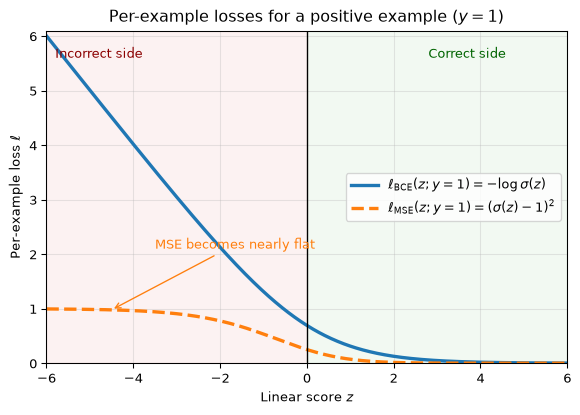

In [2]:
import matplotlib.pyplot as plt
import numpy as np

rng = np.random.default_rng(42)

# Sigmoid function
def sigmoid(t):
    return 1 / (1 + np.exp(-t))

# Compare the losses as functions of the linear score z for y = 1.
z_values = np.linspace(-6, 6, 1000)
p_values = sigmoid(z_values)
bce_values = -np.log(p_values)
mse_values = (p_values - 1) ** 2

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.axvspan(-6, 0, color='tab:red', alpha=0.06)
ax.axvspan(0, 6, color='tab:green', alpha=0.06)
ax.plot(
    z_values,
    bce_values,
    color='tab:blue',
    linewidth=2.5,
    label=r'$\ell_{\mathrm{BCE}}(z;y=1)=-\log \sigma(z)$',
)
ax.plot(
    z_values,
    mse_values,
    color='tab:orange',
    linewidth=2.5,
    linestyle='--',
    label=r'$\ell_{\mathrm{MSE}}(z;y=1)=(\sigma(z)-1)^2$',
)
ax.axvline(0, color='black', linewidth=1)

ax.text(-5.8, 5.6, 'Incorrect side', color='darkred')
ax.text(2.8, 5.6, 'Correct side', color='darkgreen')
ax.annotate(
    'MSE becomes nearly flat',
    xy=(-4.5, mse_values[np.argmin(np.abs(z_values + 4.5))]),
    xytext=(-3.5, 2.1),
    arrowprops={'arrowstyle': '->', 'color': 'tab:orange'},
    color='tab:orange',
)

ax.set_xlim(-6, 6)
ax.set_ylim(0, 6.1)
ax.set_xlabel(r'Linear score $z$')
ax.set_ylabel(r'Per-example loss $\ell$')
ax.set_title(r'Per-example losses for a positive example ($y=1$)')
ax.grid(True, alpha=0.3)
ax.legend()
plt.show()

For one example with $y=1$ and $\hat{p}=\sigma(z)$:

$$
\ell_{\mathrm{BCE}}(z;y=1)=-\log\sigma(z),
\qquad
\ell_{\mathrm{MSE}}(z;y=1)=(\sigma(z)-1)^2.
$$

For a positive example, negative scores correspond to incorrect
predictions. As $z$ becomes strongly negative, binary cross-entropy
continues to increase. The squared-error loss instead approaches 1 and
becomes nearly flat.

The small slope of the MSE curve corresponds to a small gradient, even
though the prediction is confidently incorrect. For $y=0$, the curves
are reflected horizontally.

Each curve shows the loss $\ell$ for one example. The training objective
$J(\theta)$ is the mean of these losses over the training set:

$$
J(\theta)=\frac{1}{N}\sum_{i=1}^{N}\ell(\theta^\top x_i;y_i).
$$

## Why not MSE as a Loss Function?

- **Binary cross-entropy** is the **negative log-likelihood** of the
  **Bernoulli model**.
- With **binary cross-entropy**, the logistic-regression objective is
  **convex** in the parameters.
- With **sigmoid** outputs, **MSE** is **not globally convex** in the
  linear score. Its **gradient** can also become **very small** when the
  model makes a **confidently incorrect prediction**.

We will revisit cross-entropy when studying neural networks, especially
in conjunction with the softmax function.

Optional explanations:

- [Cross Entropy vs. MSE as Cost Function for Logistic Regression for
  Classification](https://www.youtube.com/watch?v=m0ZeT1EWjjI)
- [What is the difference between negative log likelihood and cross
  entropy?](https://www.youtube.com/watch?v=ziq967YrSsc)

In linear regression, MSE is convex because the prediction is linear in
the parameters. The issue here is the composition of MSE with the
nonlinear sigmoid.

# Geometric Interpretation

## Geometric Interpretation

- Let $w=(\theta_1,\ldots,\theta_D)^\top$ denote the **feature-weight
  vector**.

- The feature-dependent part of the linear score is a **dot product**:
  $$
  w^\top x = \theta_1 x_1 + \theta_2 x_2 + \ldots + \theta_D x_D.
  $$

- The complete **linear score** includes the **intercept**: $$
  t(x)=\theta_0 + w^\top x.
  $$

- The **dot product** has a **geometric interpretation**. $$
  w^\top x = \|w\|\|x\|\cos\phi
  $$

The complete parameter vector is
$\theta=(\theta_0,\theta_1,\ldots,\theta_D)^\top$. The vector $w$
contains only the feature weights.

## Geometric Interpretation

$$
w^\top x = \|w\|\|x\|\cos\phi
$$

- The **dot product** depends on both **vector lengths** and the
  **angle** between them.
- It is **positive** when the angle is **acute** and **negative** when
  the angle is **obtuse**.
- It is **zero** when the vectors are **perpendicular**
  $(\phi=90^\circ)$.

## Geometric Interpretation

- **Logistic regression** applies the sigmoid to the linear score
  $t(x)=\theta_0+w^\top x$.

- The equation $t(x)=0$ defines a hyperplane in feature space.

- The feature-weight vector $w$ is normal to this hyperplane. The
  intercept $\theta_0$ shifts the boundary without changing its
  orientation.

## Geometric Interpretation

- The **decision boundary** is where $t(x)=0$.

- Points with $t(x)>0$ receive probability greater than $0.5$.

- Points with $t(x)<0$ receive probability less than $0.5$.

- The sigmoid converts the **linear score** into a probability. The
  signed distance to the boundary is $$
  \frac{t(x)}{\|w\|}.
  $$

# Implementation

## Implementation: Generating Data

In [3]:
# Generate synthetic data for a binary classification problem

m = 100  # number of examples
d = 2    # number of features

X = rng.standard_normal((m, d))

# Define labels using a linear decision boundary with some noise:

noise = 0.5 * rng.standard_normal(m)

y = (X[:, 0] + X[:, 1] + noise > 0).astype(int)

## Implementation: Visualization

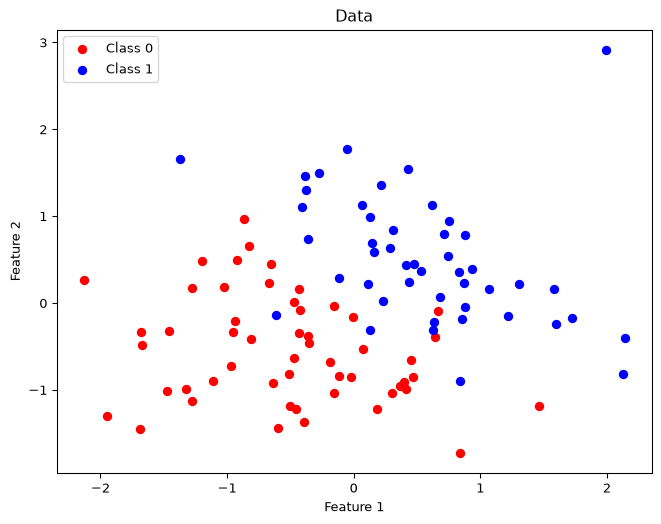

In [4]:
# Visualize the decision boundary along with the data points
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Data")
plt.legend()
plt.show()

## Implementation: Cost Function

In [5]:
# Cost function: binary cross-entropy
def cost_function(theta, X, y):
    m = len(y)
    h = sigmoid(X.dot(theta))
    h = np.clip(h, 1e-12, 1 - 1e-12)
    cost = -(1/m) * np.sum(y * np.log(h) + (1 - y) * np.log(1 - h))
    return cost

# Gradient of the cost function
def gradient(theta, X, y):
    m = len(y)
    h = sigmoid(X.dot(theta))
    grad = (1/m) * X.T.dot(h - y)
    return grad

## Implementation: Logistic Regression

In [6]:
# Logistic regression training using gradient descent
def logistic_regression(X, y, learning_rate=0.1, iterations=1000):
    m, n = X.shape
    theta = np.zeros(n)
    cost_history = []
    
    for i in range(iterations):
        theta -= learning_rate * gradient(theta, X, y)
        cost_history.append(cost_function(theta, X, y))
        
    return theta, cost_history

## Training

In [7]:
# Add intercept term (bias)
X_with_intercept = np.hstack([np.ones((m, 1)), X])

# Train the logistic regression model
theta, cost_history = logistic_regression(X_with_intercept, y, learning_rate=0.1, iterations=1000)
theta_0 = theta[0]
w = theta[1:]

print("Optimized theta:", theta)

Optimized theta: [-0.28250171  3.11670841  3.46892095]

## Cost Function Convergence

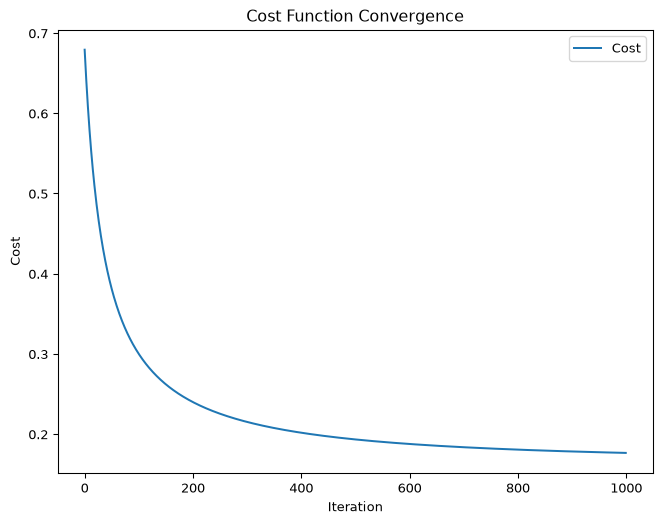

In [8]:
plt.figure(figsize=(8, 6))
plt.plot(cost_history, label="Cost")
plt.xlabel("Iteration")
plt.ylabel("Cost")
plt.title("Cost Function Convergence")
plt.legend()
plt.show()

## Decision Boundary and Data Points

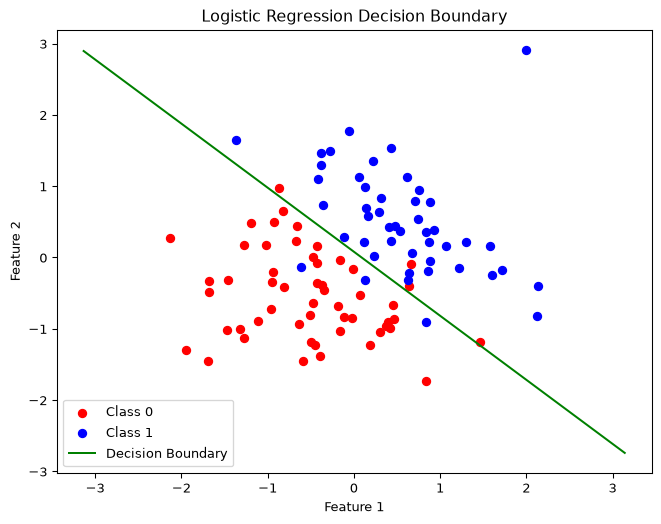

In [9]:
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

# Decision boundary: theta_0 + w[0]*x1 + w[1]*x2 = 0
x_vals = np.array([min(X[:, 0]) - 1, max(X[:, 0]) + 1])
y_vals = -(theta_0 + w[0] * x_vals) / w[1]
plt.plot(x_vals, y_vals, label='Decision Boundary', color='green')
plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary")
plt.legend()
plt.show()

## Visualizing the Weight Vector

The fitted feature-weight vector $w=(\theta_1,\theta_2)^\top$ is
**normal** to the decision boundary.

The intercept $\theta_0$ determines the position of the boundary.

## Visualizing the Weight Vector

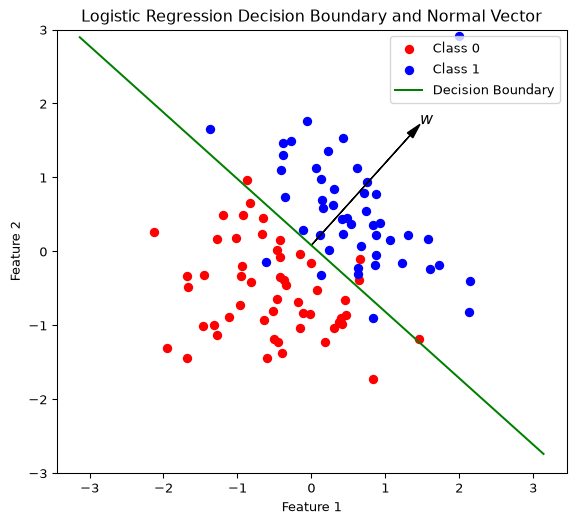

In [10]:
# Plot decision boundary and data points
plt.figure(figsize=(8, 6))
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', label='Class 1')

# Decision boundary: theta_0 + w[0]*x1 + w[1]*x2 = 0
x_vals = np.array([min(X[:, 0]) - 1, max(X[:, 0]) + 1])
y_vals = -(theta_0 + w[0] * x_vals) / w[1]
plt.plot(x_vals, y_vals, label='Decision Boundary', color='green')

# --- Draw the normal vector ---
# The normal vector is w.
# Choose a reference point on the decision boundary. Here, we use x1 = 0:
x_ref = 0
y_ref = -theta_0 / w[1]

# Copy the feature-weight vector for display.
normal = w.copy()

# Normalize and scale for display
normal_norm = np.linalg.norm(normal)
if normal_norm != 0:
    normal_unit = normal / normal_norm
else:
    normal_unit = normal
scale = 2  # adjust scale as needed
normal_display = normal_unit * scale

# Draw an arrow starting at the reference point
plt.arrow(x_ref, y_ref, normal_display[0], normal_display[1],
          head_width=0.1, head_length=0.2, fc='black', ec='black')
plt.text(x_ref + normal_display[0]*1.1, y_ref + normal_display[1]*1.1, 
         r'$w$', color='black', fontsize=12)

plt.xlabel("Feature 1")
plt.ylabel("Feature 2")
plt.title("Logistic Regression Decision Boundary and Normal Vector")
plt.legend()
plt.gca().set_aspect('equal', adjustable='box')
plt.ylim(-3, 3)
plt.show()

## Near the Decision Boundary

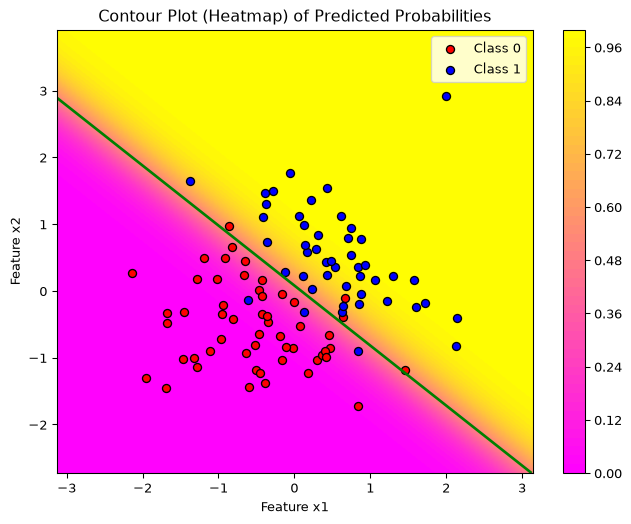

In [11]:
# --- Visualization Setup ---
# Create a grid over the feature space
x1_range = np.linspace(X[:, 0].min()-1, X[:, 0].max()+1, 100)
x2_range = np.linspace(X[:, 1].min()-1, X[:, 1].max()+1, 100)
xx1, xx2 = np.meshgrid(x1_range, x2_range)

# Construct the grid input (with intercept) for predictions
grid = np.c_[np.ones(xx1.ravel().shape), xx1.ravel(), xx2.ravel()]
# Compute predicted probabilities over the grid
probs = sigmoid(grid.dot(theta)).reshape(xx1.shape)
# --- Approach 2: 2D Contour (Heatmap) Plot ---
plt.figure(figsize=(8, 6))
contour = plt.contourf(xx1, xx2, probs, cmap='spring', levels=50)
plt.colorbar(contour)
plt.contour(xx1, xx2, probs, levels=[0.5], colors='green', linewidths=2)
plt.xlabel('Feature x1')
plt.ylabel('Feature x2')
plt.title('Contour Plot (Heatmap) of Predicted Probabilities')
# Overlay training data
plt.scatter(X[y == 0][:, 0], X[y == 0][:, 1], color='red', edgecolor='k', label='Class 0')
plt.scatter(X[y == 1][:, 0], X[y == 1][:, 1], color='blue', edgecolor='k', label='Class 1')
plt.legend()
plt.show()

# Epilogue

## Summary

- Logistic regression models the probability of a **binary outcome**.
- **Maximizing the Bernoulli likelihood** is equivalent to **minimizing
  binary cross-entropy**.
- Cross-entropy **strongly penalizes** confident, **incorrect
  predictions**.
- The equation $\theta_0+w^\top x=0$ defines the **decision boundary**,
  and the feature-weight vector $w$ is normal to it.
- **Batch gradient descent** updates the parameters using the average
  gradient over the training set.

## Next lecture

- Performance measures and model evaluation

## References

Russell, Stuart, and Peter Norvig. 2020. *Artificial Intelligence: A
Modern Approach*. 4th ed. Pearson. <http://aima.cs.berkeley.edu/>.

------------------------------------------------------------------------

Marcel **Turcotte**

<Marcel.Turcotte@uOttawa.ca>

School of Electrical Engineering and **Computer Science** (EE**CS**)

University of Ottawa